# The World’s Mood Map: Can News Tone Predict Protests, Conflict, and Diplomacy?

**Course:** Python Data Analytics  
**Dataset:** GDELT 2.0 Event Database  
**Timeline:** From 2023 to May 2026
**Core idea:** Use global news event data to explore whether media tone, event type, actor countries, and attention metrics can reveal patterns of protest, conflict, and diplomacy.

## Research Questions

1. Do countries with more negative news tone experience more conflict-related events?
2. Which event types attract the most international media attention?
3. Are diplomatic events reported with a different tone than protest or conflict events?
4. How does global event intensity change across days, weeks, and hours?
5. Can we build a simple descriptive **Global Tension Index** from news tone, event severity, and media attention?

## Data Source

GDELT 2.0 master file list:  
`http://data.gdeltproject.org/gdeltv2/masterfilelist.txt`

GDELT 2.0 event files are ZIP files ending in:  
`.export.CSV.zip`

> Important: GDELT is very large. This notebook downloads a sample of recent files,without downloading the whole database.



In [43]:
# ============================================================
# Cell 1: Import libraries
# ============================================================

import os
import re
import zipfile
import warnings
from pathlib import Path

import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "figure.dpi": 100
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
# ============================================================
# Cell 2: Project configuration
# ============================================================

# GDELT updates every 15 minutes. Its master file list contains all files
# going back to April 2015. We use a balanced temporal sampling strategy:
# we select a fixed number of files per month to ensure the dataset covers
# multiple years and months, not just the most recent day.

MASTER_FILE_URL = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

# How many months back to include in the sample.
MONTHS_BACK = 36

# How many GDELT files to download from each month.
FILES_PER_MONTH = 2

TARGET_COUNTRIES = None

# Minimum rows expected for the project.
MIN_ROWS_REQUIRED = 5000

# Folder to store downloaded files
DATA_DIR = Path("gdelt_data")
DATA_DIR.mkdir(exist_ok=True)

print("Configuration complete.")
print(f"Sampling strategy: {FILES_PER_MONTH} files/month × {MONTHS_BACK} months")
print(f"Data folder: {DATA_DIR.resolve()}")

Configuration complete.
Sampling strategy: 2 files/month × 36 months
Data folder: /Users/beltinaa/Documents/world_mood_map_notebook/gdelt_data


## GDELT 2.0 Event Column Names

Raw GDELT `.export.CSV.zip` files do **not always include a header row**, so we define the official event schema manually.

The most important variables for this project are:

- `AvgTone`: average tone of news coverage
- `GoldsteinScale`: event cooperation/conflict score
- `QuadClass`: broad class of event
- `NumMentions`: how often the event is mentioned
- `NumSources`: number of sources covering the event
- `ActionGeo_CountryCode`: country where the event action happened
- `EventRootCode`: high-level event type
- `SQLDATE`: event date

In [3]:
# ============================================================
# Cell 3: Define GDELT 2.0 event column names
# ============================================================

GDELT_COLUMNS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources",
    "NumArticles", "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_Fullname", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_Fullname", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
    "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_Fullname", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
    "ActionGeo_Long", "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL"
]

# We only load the columns needed for the project to save memory.
USE_COLUMNS = [
    "GLOBALEVENTID", "SQLDATE", "MonthYear", "Year",
    "Actor1Name", "Actor1CountryCode",
    "Actor2Name", "Actor2CountryCode",
    "EventCode", "EventBaseCode", "EventRootCode", "QuadClass",
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
    "ActionGeo_CountryCode", "ActionGeo_Fullname", "ActionGeo_Lat", "ActionGeo_Long",
    "DATEADDED", "SOURCEURL"
]

print(f"Total schema columns: {len(GDELT_COLUMNS)}")
print(f"Columns used in this notebook: {len(USE_COLUMNS)}")

Total schema columns: 61
Columns used in this notebook: 23


In [4]:
# ============================================================
# Cell 4: Download master file list and select recent export files
# ============================================================

def fetch_master_file_list(master_url: str) -> pd.DataFrame:
    """Download GDELT masterfilelist.txt and return only export CSV zip files."""
    response = requests.get(master_url, timeout=60)
    response.raise_for_status()

    rows = []
    for line in response.text.splitlines():
        parts = line.strip().split()
        if len(parts) >= 3:
            size, md5, url = parts[0], parts[1], parts[2]
            if url.endswith(".export.CSV.zip"):
                filename = url.split("/")[-1]
                timestamp_match = re.search(r"(\d{14})\.export\.CSV\.zip", filename)
                if timestamp_match:
                    timestamp = pd.to_datetime(timestamp_match.group(1), format="%Y%m%d%H%M%S")
                    rows.append({
                        "size_bytes": int(size),
                        "md5": md5,
                        "url": url,
                        "filename": filename,
                        "timestamp": timestamp
                    })

    df_files = pd.DataFrame(rows).sort_values("timestamp")
    return df_files

files_df = fetch_master_file_list(MASTER_FILE_URL)

print("Available GDELT export files:", len(files_df))
print("Date range:", files_df["timestamp"].min(), "to", files_df["timestamp"].max())
files_df.tail()

Available GDELT export files: 386868
Date range: 2015-02-18 23:00:00 to 2026-05-17 18:30:00


,size_bytes,md5,url,filename,timestamp
386863,49941,dcb2669371f80c4fea33d8bbc0e9e9d1,http://data.gdeltproject.org/gdeltv2/202605171...,20260517173000.export.CSV.zip,2026-05-17 17:30:00
386864,44503,e1433be9287279037d9307fa570e411e,http://data.gdeltproject.org/gdeltv2/202605171...,20260517174500.export.CSV.zip,2026-05-17 17:45:00
386865,49188,af461d17be4dc1b661ae9ecf7392cfb9,http://data.gdeltproject.org/gdeltv2/202605171...,20260517180000.export.CSV.zip,2026-05-17 18:00:00
386866,31870,4177fbd5d46aeaa37905af72ef02fddb,http://data.gdeltproject.org/gdeltv2/202605171...,20260517181500.export.CSV.zip,2026-05-17 18:15:00
386867,40003,77e400435f054a8f71a652fad45792ad,http://data.gdeltproject.org/gdeltv2/202605171...,20260517183000.export.CSV.zip,2026-05-17 18:30:00


In [5]:
# ============================================================
# Cell 5: Select files balanced across the last MONTHS_BACK months
# ============================================================

# Add a year-month column so we can group by time period
files_df["year_month"] = files_df["timestamp"].dt.to_period("M")

# Limit to the desired time window
cutoff_date = files_df["timestamp"].max() - pd.DateOffset(months=MONTHS_BACK)
files_window = files_df[files_df["timestamp"] >= cutoff_date].copy()

print(f"GDELT files available in the last {MONTHS_BACK} months: {len(files_window):,}")
print(f"Coverage: {files_window['timestamp'].min().strftime('%Y-%m')} to {files_window['timestamp'].max().strftime('%Y-%m')}")

# Sample FILES_PER_MONTH files from each month
balanced_frames = []
for month, group in files_window.groupby("year_month"):
    sample = group.sample(n=min(FILES_PER_MONTH, len(group)), random_state=42)
    balanced_frames.append(sample)

selected_files = pd.concat(balanced_frames).sort_values("timestamp").reset_index(drop=True)

print(f"\nSelected {len(selected_files)} files across {selected_files['year_month'].nunique()} months.")
print("\nFiles selected per month:")
print(selected_files["year_month"].value_counts().sort_index().to_string())
selected_files[["timestamp", "size_bytes", "url"]].head(10)

GDELT files available in the last 36 months: 103,519
Coverage: 2023-05 to 2026-05

Selected 74 files across 37 months.

Files selected per month:
year_month
2023-05    2
2023-06    2
2023-07    2
2023-08    2
2023-09    2
2023-10    2
2023-11    2
2023-12    2
2024-01    2
2024-02    2
2024-03    2
2024-04    2
2024-05    2
2024-06    2
2024-07    2
2024-08    2
2024-09    2
2024-10    2
2024-11    2
2024-12    2
2025-01    2
2025-02    2
2025-03    2
2025-04    2
2025-05    2
2025-06    2
2025-07    2
2025-08    2
2025-09    2
2025-10    2
2025-11    2
2025-12    2
2026-01    2
2026-02    2
2026-03    2
2026-04    2
2026-05    2
Freq: M


,timestamp,size_bytes,url
0,2023-05-18 07:15:00,87384,http://data.gdeltproject.org/gdeltv2/202305180...
1,2023-05-29 06:45:00,72814,http://data.gdeltproject.org/gdeltv2/202305290...
2,2023-06-05 21:45:00,107690,http://data.gdeltproject.org/gdeltv2/202306052...
3,2023-06-16 03:45:00,78659,http://data.gdeltproject.org/gdeltv2/202306160...
4,2023-07-26 01:00:00,133474,http://data.gdeltproject.org/gdeltv2/202307260...
5,2023-07-30 20:30:00,43108,http://data.gdeltproject.org/gdeltv2/202307302...
6,2023-08-26 00:45:00,98728,http://data.gdeltproject.org/gdeltv2/202308260...
7,2023-08-30 20:30:00,109341,http://data.gdeltproject.org/gdeltv2/202308302...
8,2023-09-05 22:00:00,115267,http://data.gdeltproject.org/gdeltv2/202309052...
9,2023-09-16 03:30:00,64807,http://data.gdeltproject.org/gdeltv2/202309160...


In [6]:
# ============================================================
# Cell 6: Download and read selected GDELT ZIP files
# ============================================================

def download_and_read_gdelt_file(url: str, data_dir: Path) -> pd.DataFrame:
    """Download one GDELT export ZIP file and read it into a DataFrame."""
    filename = url.split("/")[-1]
    local_zip_path = data_dir / filename

    # Download only if not already present
    if not local_zip_path.exists():
        print(f"Downloading {filename}...")
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        local_zip_path.write_bytes(response.content)
    else:
        print(f"Using cached file: {filename}")

    # Read zipped CSV
    with zipfile.ZipFile(local_zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            df = pd.read_csv(
                f,
                sep="\t",
                header=None,
                names=GDELT_COLUMNS,
                usecols=USE_COLUMNS,
                dtype={
                    "GLOBALEVENTID": "Int64",
                    "SQLDATE": "Int64",
                    "Year": "Int64",
                    "QuadClass": "Int64",
                    "EventRootCode": "string",
                    "EventCode": "string",
                    "EventBaseCode": "string",
                    "Actor1CountryCode": "string",
                    "Actor2CountryCode": "string",
                    "ActionGeo_CountryCode": "string",
                    "Actor1Name": "string",
                    "Actor2Name": "string",
                    "ActionGeo_Fullname": "string",
                    "SOURCEURL": "string"
                },
                encoding="latin1",
                low_memory=False
            )
    return df

frames = []

for_url_count = 0
for url in selected_files["url"]:
    try:
        frames.append(download_and_read_gdelt_file(url, DATA_DIR))
        for_url_count += 1
    except Exception as e:
        print(f"Failed to process {url}: {e}")

raw_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print(f"Files successfully loaded: {for_url_count}")
print(f"Raw rows loaded: {len(raw_df):,}")
raw_df.head()

Files successfully loaded: 74
Raw rows loaded: 86,809


,GLOBALEVENTID,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,DATEADDED,SOURCEURL
0,1103108228,20220518,202205,2022,<NA>,<NA>,UNIVERSITY,<NA>,042,042,04,1,1.9,1,1,1,0.578035,Luxembourg,LU,49.75,6.166667,20230518071500,https://delano.lu/article/girlguiding-luxembou...
1,1103108229,20220518,202205,2022,<NA>,<NA>,UNIVERSITY,<NA>,042,042,04,1,1.9,7,1,7,0.578035,United Kingdom,UK,54.00,-4.000000,20230518071500,https://delano.lu/article/girlguiding-luxembou...
2,1103108230,20220518,202205,2022,BUSINESS,<NA>,<NA>,<NA>,090,090,09,2,-2.0,10,1,10,-0.579151,<NA>,<NA>,NaN,NaN,20230518071500,https://www.butlereagle.com/20230518/burned-bu...
3,1103108231,20220518,202205,2022,UNIVERSITY,<NA>,<NA>,<NA>,043,043,04,1,2.8,8,1,8,0.578035,Luxembourg,LU,49.75,6.166667,20230518071500,https://delano.lu/article/girlguiding-luxembou...
4,1103108232,20220518,202205,2022,UNIVERSITY,<NA>,LUXEMBOURG,LUX,043,043,04,1,2.8,2,1,2,0.578035,Luxembourg,LU,49.75,6.166667,20230518071500,https://delano.lu/article/girlguiding-luxembou...


In [7]:
# ============================================================
# Cell 7: Basic cleaning and feature engineering
# ============================================================

df = raw_df.copy()

# Convert dates
df["event_date"] = pd.to_datetime(df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce")
df["dateadded"] = pd.to_datetime(df["DATEADDED"].astype(str), format="%Y%m%d%H%M%S", errors="coerce")

# Numeric conversion
numeric_cols = [
    "GoldsteinScale", "NumMentions", "NumSources", "NumArticles",
    "AvgTone", "ActionGeo_Lat", "ActionGeo_Long"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing essential analysis variables
essential_cols = ["event_date", "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "AvgTone"]
df = df.dropna(subset=essential_cols)

# Optional country filtering
if TARGET_COUNTRIES is not None:
    df = df[df["ActionGeo_CountryCode"].isin(TARGET_COUNTRIES)]

# Add readable QuadClass labels
quad_labels = {
    1: "Verbal Cooperation",
    2: "Material Cooperation",
    3: "Verbal Conflict",
    4: "Material Conflict"
}

df["quad_label"] = df["QuadClass"].map(quad_labels)

# Simplified event category
def classify_event(row):
    root = str(row["EventRootCode"]).zfill(2)
    quad = row["QuadClass"]

    if quad in [3, 4]:
        if root in ["14"]:
            return "Protest"
        elif root in ["18", "19", "20"]:
            return "Conflict / Violence"
        elif root in ["17"]:
            return "Coercion"
        else:
            return "Other Conflict"
    elif quad in [1, 2]:
        if root in ["03", "04"]:
            return "Diplomacy / Consultation"
        elif root in ["05"]:
            return "Engagement / Cooperation"
        elif root in ["06", "07"]:
            return "Material Cooperation"
        else:
            return "Other Cooperation"
    else:
        return "Other"

df["event_category"] = df.apply(classify_event, axis=1)

# Attention score: combines mentions, sources, and articles.
# log1p prevents very large media spikes from dominating everything.
df["attention_score"] = (
    np.log1p(df["NumMentions"]) +
    np.log1p(df["NumSources"]) +
    np.log1p(df["NumArticles"])
)

# Negative tone strength
df["negative_tone"] = np.where(df["AvgTone"] < 0, abs(df["AvgTone"]), 0)

# Conflict flag
df["is_conflict"] = df["QuadClass"].isin([3, 4]).astype(int)
df["is_material_conflict"] = (df["QuadClass"] == 4).astype(int)
df["is_diplomacy"] = df["event_category"].isin(["Diplomacy / Consultation", "Engagement / Cooperation"]).astype(int)
df["is_protest"] = (df["event_category"] == "Protest").astype(int)

# Time features
df["hour_added"] = df["dateadded"].dt.hour
df["weekday"] = df["event_date"].dt.day_name()
df["week"] = df["event_date"].dt.to_period("W").astype(str)

print(f"Cleaned rows: {len(df):,}")

if len(df) < MIN_ROWS_REQUIRED:
    print("WARNING: The dataset has fewer rows than required. Increase MAX_FILES and rerun the download cells.")

df.head()

Cleaned rows: 86,809


,GLOBALEVENTID,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,DATEADDED,SOURCEURL,event_date,dateadded,quad_label,event_category,attention_score,negative_tone,is_conflict,is_material_conflict,is_diplomacy,is_protest,hour_added,weekday,week
0,1103108228,20220518,202205,2022,<NA>,<NA>,UNIVERSITY,<NA>,042,042,04,1,1.9,1,1,1,0.578035,Luxembourg,LU,49.75,6.166667,20230518071500,https://delano.lu/article/girlguiding-luxembou...,2022-05-18,2023-05-18 07:15:00,Verbal Cooperation,Diplomacy / Consultation,2.079442,0.000000,0,0,1,0,7,Wednesday,2022-05-16/2022-05-22
1,1103108229,20220518,202205,2022,<NA>,<NA>,UNIVERSITY,<NA>,042,042,04,1,1.9,7,1,7,0.578035,United Kingdom,UK,54.00,-4.000000,20230518071500,https://delano.lu/article/girlguiding-luxembou...,2022-05-18,2023-05-18 07:15:00,Verbal Cooperation,Diplomacy / Consultation,4.852030,0.000000,0,0,1,0,7,Wednesday,2022-05-16/2022-05-22
2,1103108230,20220518,202205,2022,BUSINESS,<NA>,<NA>,<NA>,090,090,09,2,-2.0,10,1,10,-0.579151,<NA>,<NA>,NaN,NaN,20230518071500,https://www.butlereagle.com/20230518/burned-bu...,2022-05-18,2023-05-18 07:15:00,Material Cooperation,Other Cooperation,5.488938,0.579151,0,0,0,0,7,Wednesday,2022-05-16/2022-05-22
3,1103108231,20220518,202205,2022,UNIVERSITY,<NA>,<NA>,<NA>,043,043,04,1,2.8,8,1,8,0.578035,Luxembourg,LU,49.75,6.166667,20230518071500,https://delano.lu/article/girlguiding-luxembou...,2022-05-18,2023-05-18 07:15:00,Verbal Cooperation,Diplomacy / Consultation,5.087596,0.000000,0,0,1,0,7,Wednesday,2022-05-16/2022-05-22
4,1103108232,20220518,202205,2022,UNIVERSITY,<NA>,LUXEMBOURG,LUX,043,043,04,1,2.8,2,1,2,0.578035,Luxembourg,LU,49.75,6.166667,20230518071500,https://delano.lu/article/girlguiding-luxembou...,2022-05-18,2023-05-18 07:15:00,Verbal Cooperation,Diplomacy / Consultation,2.890372,0.000000,0,0,1,0,7,Wednesday,2022-05-16/2022-05-22


In [8]:
# ============================================================
# Cell 8: Dataset quality check
# ============================================================

print("Shape:", df.shape)
print("\nMissing values in selected columns:")
print(df[USE_COLUMNS].isna().mean().sort_values(ascending=False).head(15))

print("\nEvent date range:")
print(df["event_date"].min(), "to", df["event_date"].max())

print("\nRecords per year:")
year_counts = df["event_date"].dt.year.value_counts().sort_index()
print(year_counts.to_string())

print("\nRecords per year-month:")
month_counts = df["event_date"].dt.to_period("M").value_counts().sort_index()
print(month_counts.to_string())

print("\nUnique countries:", df["ActionGeo_CountryCode"].nunique())
print("\nQuadClass distribution:")
print(df["quad_label"].value_counts(dropna=False))

Shape: (86809, 36)

Missing values in selected columns:
Actor2CountryCode        0.563743
Actor1CountryCode        0.438549
Actor2Name               0.298091
Actor1Name               0.098100
ActionGeo_Lat            0.030135
ActionGeo_Fullname       0.030135
ActionGeo_Long           0.030066
ActionGeo_CountryCode    0.029997
GLOBALEVENTID            0.000000
NumSources               0.000000
DATEADDED                0.000000
AvgTone                  0.000000
NumArticles              0.000000
QuadClass                0.000000
NumMentions              0.000000
dtype: float64

Event date range:
2013-06-07 00:00:00 to 2026-05-02 00:00:00

Records per year:
event_date
2013        2
2014        1
2022      204
2023    20471
2024    28689
2025    27040
2026    10402

Records per year-month:
event_date
2013-06       1
2013-08       1
2014-11       1
2022-05      35
2022-06      21
2022-07      17
2022-08      19
2022-09      45
2022-10      33
2022-11      20
2022-12      14
2023-01      76
2

## Date Coverage Verification

Before starting the analysis, we check whether the dataset is balanced across
time. If one month dominates the sample (more than 80% of records), we apply
a secondary balancing step to ensure fair representation across all available
months. This step is important because downstream graphs that show trends
**over time** would be misleading if the data comes mostly from a single period.

In [9]:
# ============================================================
# Date Coverage Check and Secondary Balancing
# ============================================================

df["year_month_period"] = df["event_date"].dt.to_period("M")

month_distribution = df["year_month_period"].value_counts().sort_index()
dominant_share = month_distribution.max() / len(df)

print(f"Total records: {len(df):,}")
print(f"Number of months represented: {month_distribution.shape[0]}")
print(f"Most represented month: {month_distribution.idxmax()} "
      f"({month_distribution.max():,} records, {dominant_share:.1%} of total)")

if dominant_share > 0.75 and month_distribution.shape[0] < 6:
    print("\nWARNING: Dataset is heavily skewed toward one month.")
    print("Applying secondary balanced sampling: up to 300 records per month.")

    MAX_PER_MONTH = 300
    balanced_frames = []
    for period, group in df.groupby("year_month_period"):
        if len(group) > MAX_PER_MONTH:
            balanced_frames.append(group.sample(n=MAX_PER_MONTH, random_state=42))
        else:
            balanced_frames.append(group)

    df = pd.concat(balanced_frames, ignore_index=True)
    df["year_month_period"] = df["event_date"].dt.to_period("M")
    print(f"\nAfter secondary balancing: {len(df):,} records across "
          f"{df['year_month_period'].nunique()} months.")
else:
    print("\nDate coverage looks balanced. No secondary sampling needed.")

print("\nFinal records per month:")
print(df["year_month_period"].value_counts().sort_index().to_string())

Total records: 86,809
Number of months represented: 52
Most represented month: 2024-01 (4,103 records, 4.7% of total)

Date coverage looks balanced. No secondary sampling needed.

Final records per month:
year_month_period
2013-06       1
2013-08       1
2014-11       1
2022-05      35
2022-06      21
2022-07      17
2022-08      19
2022-09      45
2022-10      33
2022-11      20
2022-12      14
2023-01      76
2023-02      29
2023-03       9
2023-04      26
2023-05    2375
2023-06    2661
2023-07    2795
2023-08    3108
2023-09    2635
2023-10    3185
2023-11    1949
2023-12    1623
2024-01    4103
2024-02    2083
2024-03    2588
2024-04    2279
2024-05    2185
2024-06    1862
2024-07    2764
2024-08    2247
2024-09    2167
2024-10    2435
2024-11    2220
2024-12    1756
2025-01    2035
2025-02    2198
2025-03    2613
2025-04    1733
2025-05    2183
2025-06    3438
2025-07    3012
2025-08    2769
2025-09    1922
2025-10    2099
2025-11    1637
2025-12    1401
2026-01    1975
2026-02  

In [10]:
# ============================================================
# Cell 9: Descriptive statistics
# ============================================================

summary_cols = ["AvgTone", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "attention_score"]
df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AvgTone,86809.0,-2.158710,4.203579,-26.315789,-4.900459,-2.090592,0.662252,16.770186
GoldsteinScale,86809.0,0.433867,4.707900,-10.000000,-2.000000,1.000000,3.400000,10.000000
NumMentions,86809.0,4.719511,4.440017,1.000000,2.000000,4.000000,6.000000,200.000000
NumSources,86809.0,1.044488,0.390217,1.000000,1.000000,1.000000,1.000000,14.000000
NumArticles,86809.0,4.611791,4.170160,1.000000,2.000000,4.000000,6.000000,140.000000
attention_score,86809.0,3.802193,1.213408,2.079442,2.890372,3.912023,4.584967,12.605570


# Analysis Question 1

## Do countries with more negative news tone experience more conflict-related events?

We aggregate by country and compare:

- average tone
- conflict event share
- material conflict share
- total number of events
- average Goldstein Scale
- average media attention

In [11]:
# ============================================================
# Cell 10: Country-level mood/conflict table
# ============================================================

country_stats = (
    df.dropna(subset=["ActionGeo_CountryCode"])
      .groupby("ActionGeo_CountryCode")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          median_tone=("AvgTone", "median"),
          conflict_share=("is_conflict", "mean"),
          material_conflict_share=("is_material_conflict", "mean"),
          protest_share=("is_protest", "mean"),
          diplomacy_share=("is_diplomacy", "mean"),
          avg_goldstein=("GoldsteinScale", "mean"),
          avg_attention=("attention_score", "mean"),
          total_mentions=("NumMentions", "sum")
      )
      .reset_index()
)

# Keep countries with enough observations for reliable comparison
country_stats = country_stats[country_stats["events"] >= 20].copy()

country_stats.sort_values("conflict_share", ascending=False).head(10)

,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions
211,WE,247,-7.213307,-6.880734,0.672065,0.538462,0.044534,0.161943,-4.918623,2.914684,608
45,CS,40,1.245829,1.587302,0.575000,0.100000,0.000000,0.300000,-1.560000,3.595943,154
151,PA,21,-3.440884,-4.088050,0.571429,0.190476,0.000000,0.047619,-1.933333,3.997271,99
59,ES,86,-3.428969,-4.114559,0.534884,0.162791,0.000000,0.325581,-1.043023,3.452398,283
51,DJ,30,-2.784831,-2.488809,0.533333,0.300000,0.000000,0.200000,-2.293333,3.883592,144
181,SU,162,-4.882968,-4.956897,0.487654,0.320988,0.006173,0.185185,-1.803704,3.637667,667
53,EC,80,-5.134677,-5.497771,0.487500,0.425000,0.000000,0.337500,-1.932500,3.916117,388
71,GG,27,-6.327863,-6.764706,0.481481,0.185185,0.111111,0.333333,-1.959259,4.032503,139
127,ML,32,-5.048344,-4.712644,0.468750,0.125000,0.031250,0.187500,-0.803125,3.901155,152
214,YM,140,-3.851130,-4.414003,0.464286,0.257143,0.000000,0.271429,-2.007857,3.312572,469


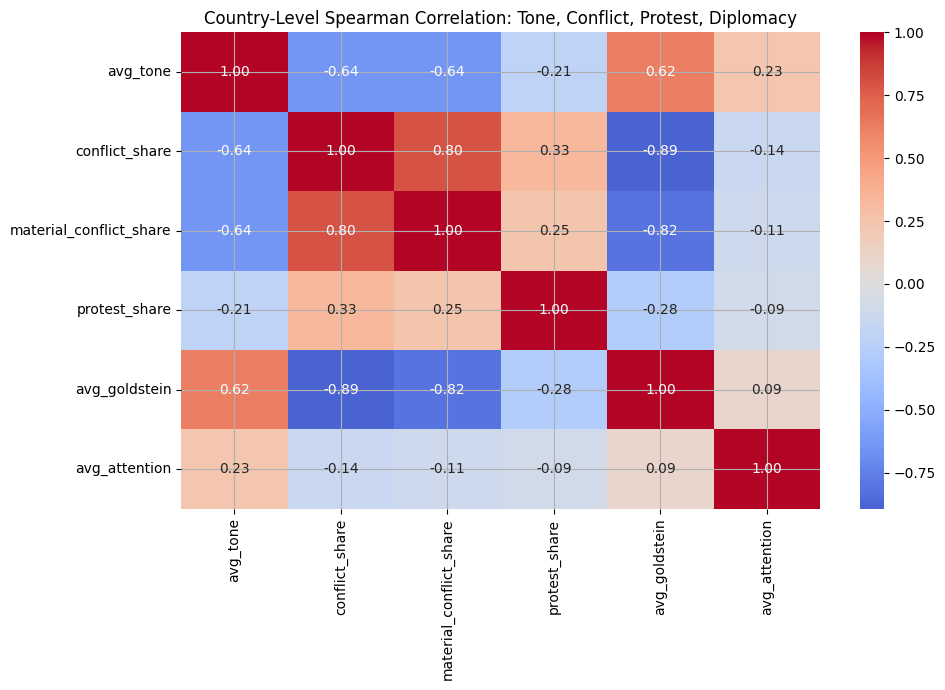

In [12]:
# ============================================================
# Cell 11: Correlation between tone and conflict indicators
# ============================================================

corr_cols = ["avg_tone", "conflict_share", "material_conflict_share", "protest_share", "avg_goldstein", "avg_attention"]
country_corr = country_stats[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(country_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Country-Level Spearman Correlation: Tone, Conflict, Protest, Diplomacy")
plt.tight_layout()
plt.show()

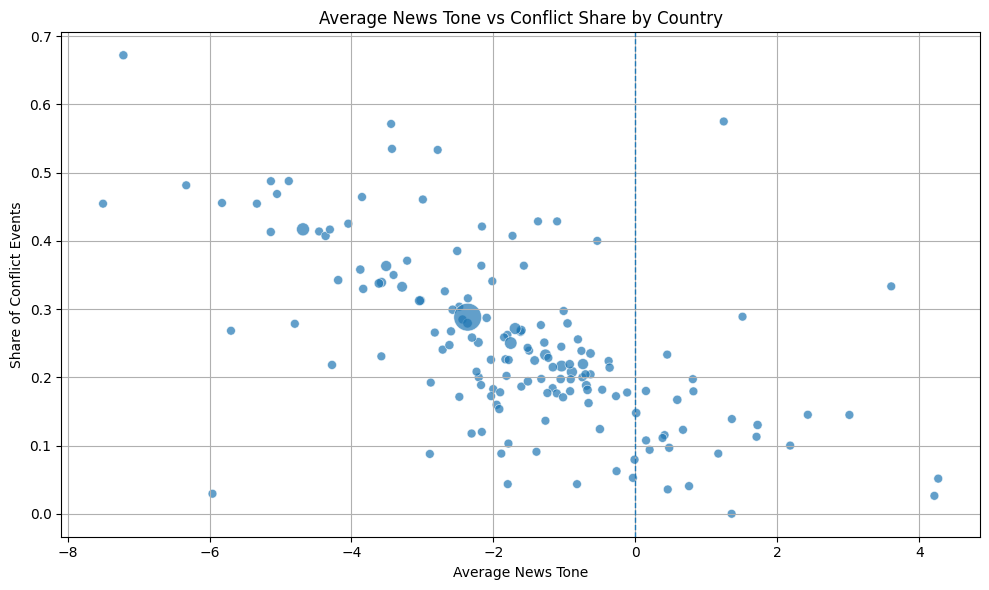

In [13]:
# ============================================================
# Cell 12: Scatter plot — average tone vs conflict share
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=country_stats,
    x="avg_tone",
    y="conflict_share",
    size="events",
    sizes=(40, 400),
    alpha=0.7,
    legend=False
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Average News Tone vs Conflict Share by Country")
plt.xlabel("Average News Tone")
plt.ylabel("Share of Conflict Events")
plt.tight_layout()
plt.show()


**Interpretation:** This scatter plot helps check whether countries with more negative average tone also have a higher share of conflict events. If the points do not form a clear pattern, the relationship should be interpreted as weak or uncertain, not as proof of causation.

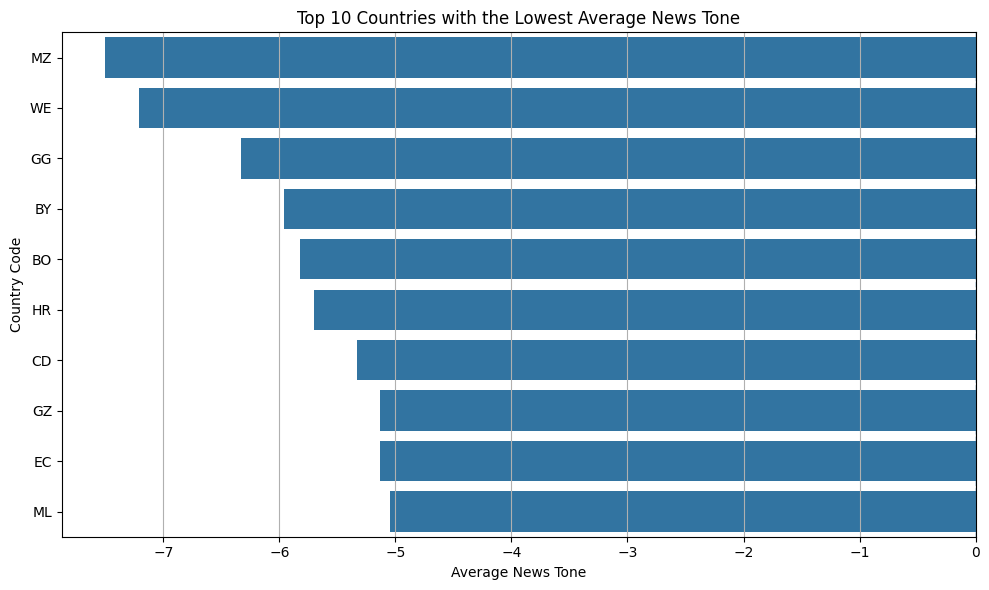

,ActionGeo_CountryCode,events,avg_tone,conflict_share,avg_goldstein
137,MZ,22,-7.500037,0.454545,-0.909091
211,WE,247,-7.213307,0.672065,-4.918623
71,GG,27,-6.327863,0.481481,-1.959259
32,BY,34,-5.958009,0.029412,2.629412
27,BO,90,-5.823648,0.455556,-0.642222
88,HR,41,-5.697348,0.268293,0.180488
35,CD,55,-5.331972,0.454545,-2.356364
84,GZ,230,-5.136439,0.413043,-1.503478
53,EC,80,-5.134677,0.487500,-1.932500
127,ML,32,-5.048344,0.468750,-0.803125


In [14]:
# ============================================================
# Cell 13: Bar chart — countries with the lowest average tone
# ============================================================

lowest_tone_countries = country_stats.sort_values("avg_tone").head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lowest_tone_countries,
    x="avg_tone",
    y="ActionGeo_CountryCode"
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top 10 Countries with the Lowest Average News Tone")
plt.xlabel("Average News Tone")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

lowest_tone_countries[["ActionGeo_CountryCode", "events", "avg_tone", "conflict_share", "avg_goldstein"]]


**Interpretation:** This bar chart highlights countries where the selected sample of news events has the lowest average tone. A low tone may reflect conflict, crisis, or negative media coverage, but it can also be affected by how often international media reports on a country.

# Analysis Question 2

## Which event types attract the most international media attention?

We rank event categories using:

- total events
- total mentions
- average number of sources
- average attention score
- average tone
- average Goldstein Scale

In [15]:
# ============================================================
# Cell 14: Event-category attention table
# ============================================================

category_stats = (
    df.groupby("event_category")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          avg_goldstein=("GoldsteinScale", "mean"),
          avg_mentions=("NumMentions", "mean"),
          total_mentions=("NumMentions", "sum"),
          avg_sources=("NumSources", "mean"),
          avg_articles=("NumArticles", "mean"),
          avg_attention=("attention_score", "mean"),
          conflict_share=("is_conflict", "mean")
      )
      .reset_index()
      .sort_values("avg_attention", ascending=False)
)

category_stats

,event_category,events,avg_tone,avg_goldstein,avg_mentions,total_mentions,avg_sources,avg_articles,avg_attention,conflict_share
4,Material Cooperation,5060,-0.948869,6.927332,5.151779,26068,1.042688,5.060474,3.961931,0.0
7,Protest,829,-3.360002,-6.604946,5.220748,4328,1.085645,5.030157,3.890047,1.0
5,Other Conflict,11479,-3.516228,-3.430543,4.765485,54703,1.041119,4.673752,3.831438,1.0
6,Other Cooperation,23899,-2.315143,1.438663,4.719821,112799,1.043977,4.623666,3.812254,0.0
0,Coercion,4566,-5.682328,-5.306045,4.799387,21914,1.051467,4.639509,3.809981,1.0
2,Diplomacy / Consultation,26094,-0.871843,2.959784,4.647199,121264,1.046677,4.541236,3.771445,0.0
3,Engagement / Cooperation,7632,0.347958,4.080149,4.594602,35066,1.034198,4.482311,3.767380,0.0
1,Conflict / Violence,7250,-5.251941,-9.801586,4.628138,33554,1.046621,4.486345,3.743605,1.0


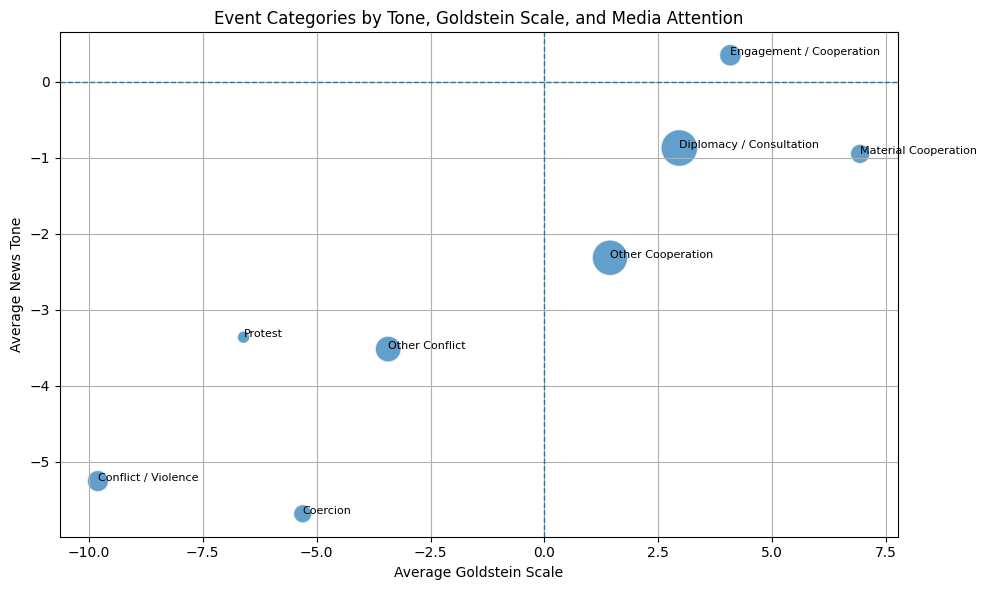

In [16]:
# ============================================================
# Cell 15: Scatter plot — media attention by event category
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=category_stats,
    x="avg_goldstein",
    y="avg_tone",
    size="total_mentions",
    sizes=(80, 700),
    alpha=0.7,
    legend=False
)

for _, row in category_stats.iterrows():
    plt.text(row["avg_goldstein"], row["avg_tone"], row["event_category"], fontsize=8)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Event Categories by Tone, Goldstein Scale, and Media Attention")
plt.xlabel("Average Goldstein Scale")
plt.ylabel("Average News Tone")
plt.tight_layout()
plt.show()


**Interpretation:** This graph compares event categories using tone, Goldstein Scale, and media attention. Categories located closer to the negative side of the Goldstein Scale usually represent more conflict-oriented events, while cooperative categories tend to have more positive scores.

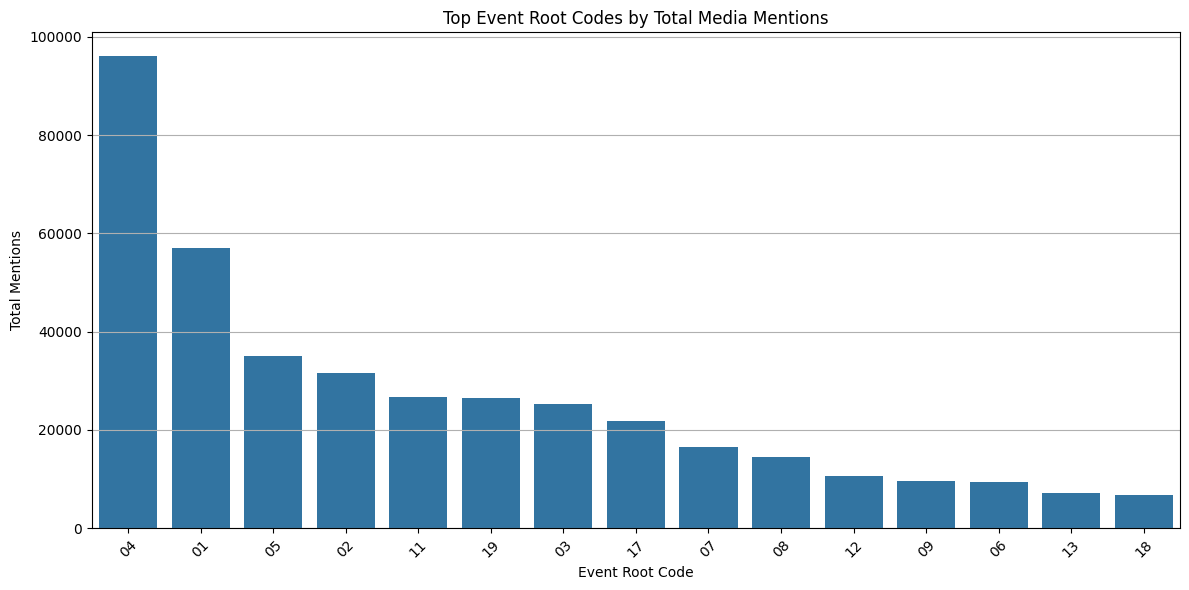

,EventRootCode,events,total_mentions,avg_tone,avg_goldstein
3,04,20917,96081,-0.985145,2.633556
0,01,12792,57077,-2.295836,0.014267
4,05,7632,35066,0.347958,4.080149
1,02,6196,31503,-1.916539,2.931423
10,11,5705,26674,-3.828512,-2.000000
18,19,5719,26535,-5.039959,-9.961444
2,03,5177,25183,-0.414064,4.277864
16,17,4566,21914,-5.682328,-5.306045
6,07,3170,16615,-0.816220,7.326088
7,08,3035,14508,-2.464926,6.520264


In [17]:
# ============================================================
# Cell 16: Bar chart — top event root codes by total mentions
# ============================================================

root_stats = (
    df.groupby("EventRootCode")
      .agg(
          events=("GLOBALEVENTID", "count"),
          total_mentions=("NumMentions", "sum"),
          avg_tone=("AvgTone", "mean"),
          avg_goldstein=("GoldsteinScale", "mean")
      )
      .reset_index()
      .sort_values("total_mentions", ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=root_stats, x="EventRootCode", y="total_mentions")
plt.title("Top Event Root Codes by Total Media Mentions")
plt.xlabel("Event Root Code")
plt.ylabel("Total Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

root_stats

**Interpretation:** The bar chart shows which high-level event root codes receive the most media mentions. This helps identify the types of events that dominate the selected GDELT sample.

# Analysis Question 3

## Are diplomatic events reported with a different tone than protest or conflict events?

Here we compare distributions of `AvgTone` and `GoldsteinScale` across event categories.

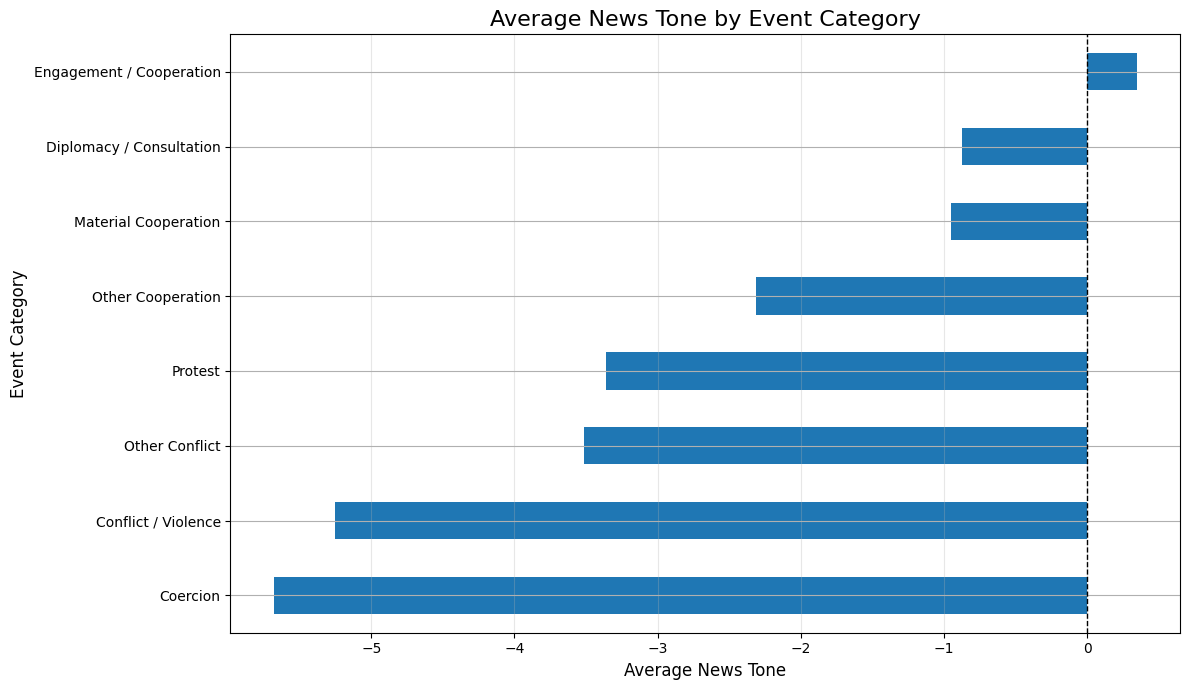

In [18]:
# ============================================================
# Cell 17: Average News Tone by Event Category
# ============================================================

# Keep only categories with enough observations
major_categories = (
    category_stats[category_stats["events"] >= 50]["event_category"]
    .tolist()
)

df_major = df[df["event_category"].isin(major_categories)].copy()

# Calculate average tone by category
tone_by_category = (
    df_major
    .groupby("event_category")["AvgTone"]
    .mean()
    .sort_values()
)

# Plot horizontal bar chart
plt.figure(figsize=(12, 7))

tone_by_category.plot(kind="barh")

# Add zero line to separate negative and positive tone
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title("Average News Tone by Event Category", fontsize=16)
plt.xlabel("Average News Tone", fontsize=12)
plt.ylabel("Event Category", fontsize=12)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The boxplot compares the distribution of news tone across event categories. This is useful because averages alone may hide variation inside each event type.

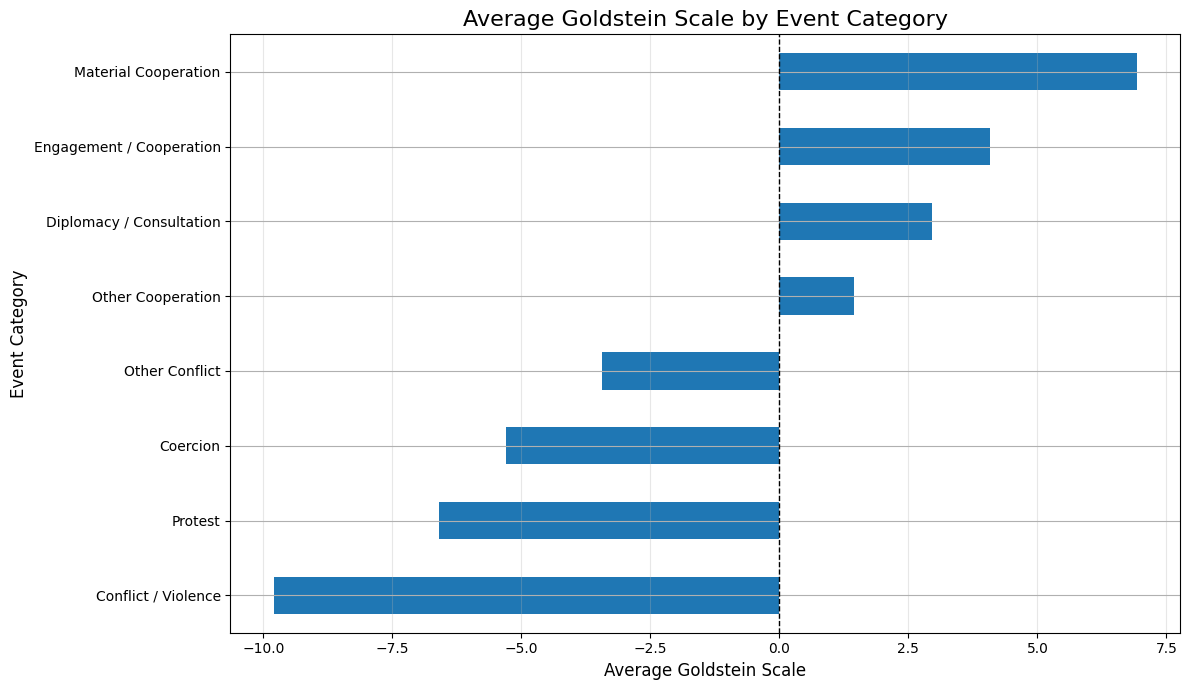

In [19]:
# ============================================================
# Average Goldstein Scale by Event Category
# ============================================================

# Remove rows with missing values
goldstein_df = df.dropna(subset=["event_category", "GoldsteinScale"]).copy()

# Keep only the top 10 categories by number of events
top_categories = (
    goldstein_df["event_category"]
    .value_counts()
    .head(10)
    .index
)

goldstein_df = goldstein_df[
    goldstein_df["event_category"].isin(top_categories)
]

# Calculate average Goldstein Scale by event category
goldstein_avg = (
    goldstein_df
    .groupby("event_category")["GoldsteinScale"]
    .mean()
    .sort_values()
)

# Plot horizontal bar chart
plt.figure(figsize=(12, 7))

goldstein_avg.plot(kind="barh")

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title("Average Goldstein Scale by Event Category", fontsize=16)
plt.xlabel("Average Goldstein Scale", fontsize=12)
plt.ylabel("Event Category", fontsize=12)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The Goldstein Scale boxplot shows how cooperative or conflict-oriented each event category is. Negative values generally indicate more conflict-related behavior, while positive values indicate more cooperative behavior.

In [20]:
# ============================================================
# Cell 19: Summary comparison: diplomacy vs protest vs conflict
# ============================================================

comparison_groups = df[df["event_category"].isin([
    "Diplomacy / Consultation",
    "Engagement / Cooperation",
    "Protest",
    "Conflict / Violence",
    "Coercion"
])].copy()

comparison_summary = (
    comparison_groups.groupby("event_category")
    .agg(
        events=("GLOBALEVENTID", "count"),
        avg_tone=("AvgTone", "mean"),
        median_tone=("AvgTone", "median"),
        avg_goldstein=("GoldsteinScale", "mean"),
        avg_mentions=("NumMentions", "mean"),
        avg_sources=("NumSources", "mean")
    )
    .reset_index()
    .sort_values("avg_goldstein")
)

comparison_summary

,event_category,events,avg_tone,median_tone,avg_goldstein,avg_mentions,avg_sources
1,Conflict / Violence,7250,-5.251941,-5.273438,-9.801586,4.628138,1.046621
4,Protest,829,-3.360002,-3.336260,-6.604946,5.220748,1.085645
0,Coercion,4566,-5.682328,-5.572289,-5.306045,4.799387,1.051467
2,Diplomacy / Consultation,26094,-0.871843,-0.740741,2.959784,4.647199,1.046677
3,Engagement / Cooperation,7632,0.347958,0.484653,4.080149,4.594602,1.034198


# Analysis Question 4

## How does global event intensity change across time?

We study:

- daily volume of events
- daily average tone
- daily conflict share
- hourly activity patterns

In [21]:
# ============================================================
# Cell 20: Daily time-series table
# ============================================================

daily = (
    df.groupby("event_date")
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          conflict_share=("is_conflict", "mean"),
          protest_events=("is_protest", "sum"),
          diplomacy_events=("is_diplomacy", "sum"),
          total_mentions=("NumMentions", "sum"),
          avg_attention=("attention_score", "mean")
      )
      .reset_index()
      .sort_values("event_date")
)

daily["rolling_avg_tone"] = daily["avg_tone"].rolling(3, min_periods=1).mean()
daily["rolling_conflict_share"] = daily["conflict_share"].rolling(3, min_periods=1).mean()

daily.head()

,event_date,events,avg_tone,conflict_share,protest_events,diplomacy_events,total_mentions,avg_attention,rolling_avg_tone,rolling_conflict_share
0,2013-06-07,1,1.731602,0.00,0,1,10,5.488938,1.731602,0.000000
1,2013-08-01,1,1.472754,0.00,0,0,2,2.890372,1.602178,0.000000
2,2014-11-02,1,-2.509804,0.00,0,0,10,5.488938,0.231517,0.000000
3,2022-05-18,10,-0.306997,0.00,0,6,60,4.176777,-0.448016,0.000000
4,2022-05-29,25,-2.405211,0.44,0,10,97,3.542545,-1.740671,0.146667


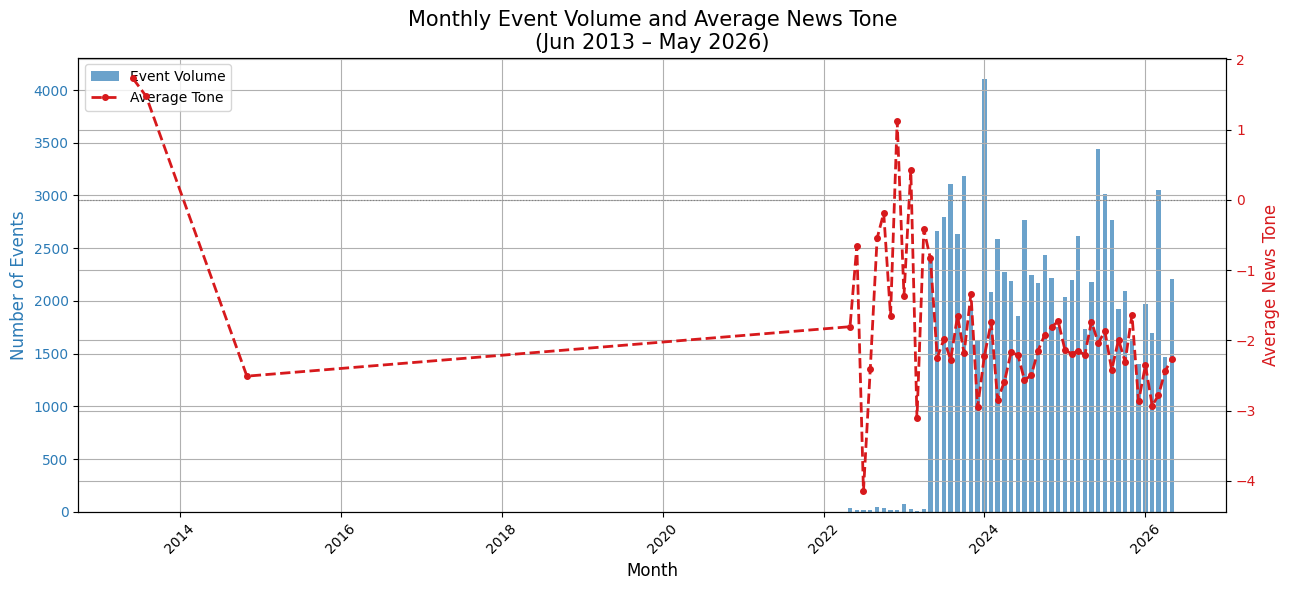

In [22]:
# ============================================================
# Cell 21: Event volume and average tone over time (monthly)
# ============================================================

# Monthly aggregation reduces noise from day-to-day variation
# and makes the trend line much easier to read in a research paper.
monthly = (
    df.groupby(df["event_date"].dt.to_period("M"))
      .agg(
          events=("GLOBALEVENTID", "count"),
          avg_tone=("AvgTone", "mean"),
          conflict_share=("is_conflict", "mean"),
          protest_events=("is_protest", "sum"),
          diplomacy_events=("is_diplomacy", "sum"),
          total_mentions=("NumMentions", "sum"),
          avg_attention=("attention_score", "mean")
      )
      .reset_index()
)
monthly["event_month"] = monthly["event_date"].dt.to_timestamp()
monthly = monthly.sort_values("event_month")

fig, ax1 = plt.subplots(figsize=(13, 6))

color_events = "#2c7bb6"
color_tone   = "#d7191c"

ax1.bar(monthly["event_month"], monthly["events"], width=20,
        color=color_events, alpha=0.7, label="Event Volume")
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Number of Events", fontsize=12, color=color_events)
ax1.tick_params(axis="y", labelcolor=color_events)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["event_month"], monthly["avg_tone"],
         color=color_tone, linewidth=2, marker="o", markersize=4,
         linestyle="--", label="Average Tone")
ax2.set_ylabel("Average News Tone", fontsize=12, color=color_tone)
ax2.tick_params(axis="y", labelcolor=color_tone)
ax2.axhline(0, color="gray", linestyle=":", linewidth=0.8)

date_range = f"{monthly['event_month'].min().strftime('%b %Y')} – {monthly['event_month'].max().strftime('%b %Y')}"
plt.title(f"Monthly Event Volume and Average News Tone\n({date_range})", fontsize=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.show()

**Interpretation:** This time-series graph compares event volume with average tone. Peaks in event volume may represent periods of stronger news activity, while the tone line shows whether the sample becomes more negative or positive over time.

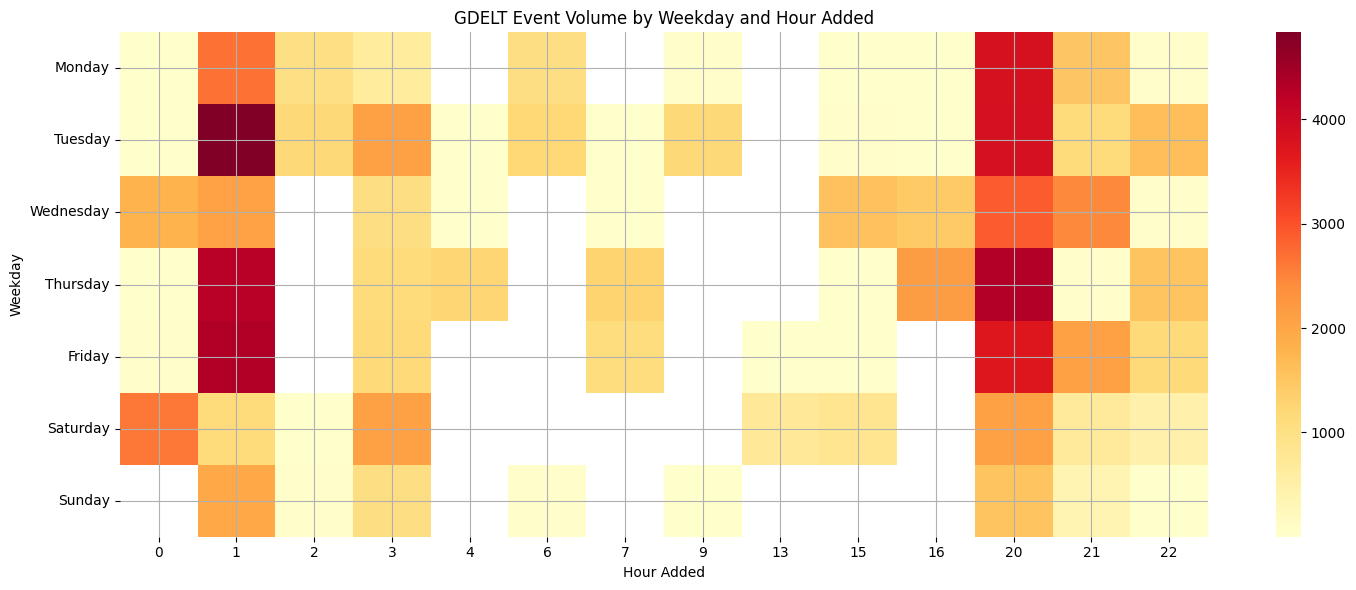

In [23]:
# ============================================================
# Cell 22: Heatmap — events by weekday and hour
# ============================================================

hour_weekday = (
    df.dropna(subset=["hour_added", "weekday"])
      .groupby(["weekday", "hour_added"])
      .size()
      .reset_index(name="events")
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hour_pivot = hour_weekday.pivot(index="weekday", columns="hour_added", values="events")
hour_pivot = hour_pivot.reindex(weekday_order)

plt.figure(figsize=(15, 6))
sns.heatmap(hour_pivot, cmap="YlOrRd")
plt.title("GDELT Event Volume by Weekday and Hour Added")
plt.xlabel("Hour Added")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap shows when events appear most often by weekday and hour. This is useful for understanding the time structure of the collected GDELT sample.

Date range in dataset:
2013-06-07 00:00:00 to 2026-05-02 00:00:00

Events by year:
event_date
2013        2
2014        1
2022      204
2023    20471
2024    28689
2025    27040
2026    10402
Name: count, dtype: int64


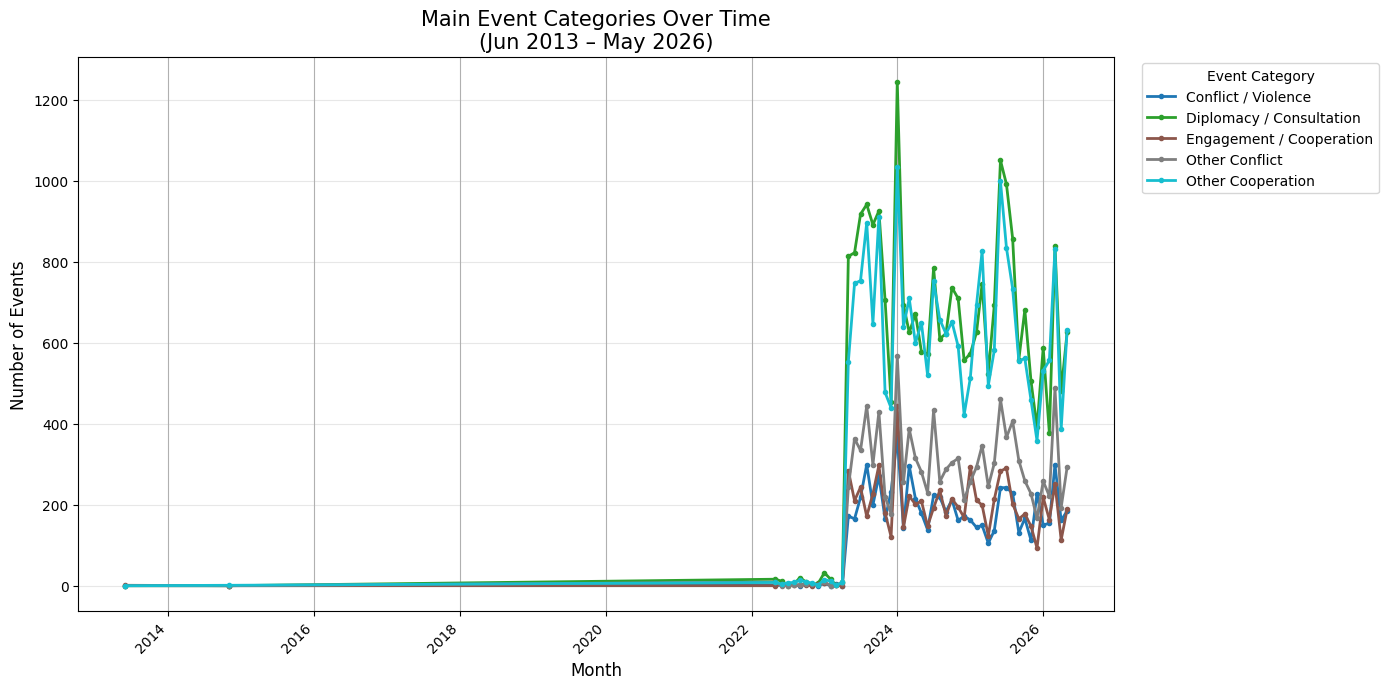

In [24]:
# ============================================================
# Main Event Categories Over Time (monthly line chart)
# ============================================================

df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

category_time_df = df.dropna(subset=["event_date", "event_category"]).copy()

print("Date range in dataset:")
print(category_time_df["event_date"].min(), "to", category_time_df["event_date"].max())
print("\nEvents by year:")
print(category_time_df["event_date"].dt.year.value_counts().sort_index())

# Group by month
category_time_df["event_month"] = (
    category_time_df["event_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Keep only the top 5 categories
top5 = (
    category_time_df["event_category"]
    .value_counts()
    .head(5)
    .index
)

category_time_df = category_time_df[
    category_time_df["event_category"].isin(top5)
]

# Count events per month per category
category_time_table = (
    category_time_df
    .groupby(["event_month", "event_category"])
    .size()
    .unstack(fill_value=0)
)

num_months = len(category_time_table)

# Use a stacked bar if few months; use a line chart if many
if num_months <= 18:
    ax = category_time_table.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7),
        width=0.8,
        colormap="tab10"
    )
    plt.xticks(
        range(len(category_time_table.index)),
        [str(m.strftime("%b %Y")) for m in category_time_table.index],
        rotation=45,
        ha="right"
    )
    plt.xlabel("Month", fontsize=12)
else:
    ax = category_time_table.plot(
        kind="line",
        figsize=(14, 7),
        colormap="tab10",
        linewidth=2,
        marker="o",
        markersize=3
    )
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Month", fontsize=12)

date_range = (
    f"{category_time_table.index.min().strftime('%b %Y')} – "
    f"{category_time_table.index.max().strftime('%b %Y')}"
)
plt.title(
    f"Main Event Categories Over Time\n({date_range})",
    fontsize=15
)
plt.ylabel("Number of Events", fontsize=12)
plt.legend(title="Event Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The stacked area chart shows how the main event categories change over time. It helps show whether conflict, diplomacy, protest, or cooperation dominates specific periods in the sample.

# Bonus Analysis

## Global Tension Index

We create a simple index using:

- negative tone
- conflict share
- material conflict share
- media attention
- inverse Goldstein score

This is not an official index. It is a student-created analytical metric for storytelling and ranking.

In [25]:
# ============================================================
# Cell 24: Build country-level Global Tension Index
# ============================================================

# This is a simple student-created index. It avoids advanced ML preprocessing
# and uses only pandas/numpy operations.
tension = country_stats.copy()

tension["negative_tone_score"] = np.maximum(-tension["avg_tone"], 0)
tension["inverse_goldstein"] = np.maximum(-tension["avg_goldstein"], 0)

index_features = [
    "negative_tone_score",
    "conflict_share",
    "material_conflict_share",
    "avg_attention",
    "inverse_goldstein"
]

# Min-max scale each component to 0-1 before averaging.
for col in index_features:
    min_value = tension[col].min()
    max_value = tension[col].max()
    if max_value != min_value:
        tension[col + "_scaled"] = (tension[col] - min_value) / (max_value - min_value)
    else:
        tension[col + "_scaled"] = 0

scaled_cols = [col + "_scaled" for col in index_features]
tension["global_tension_index_0_100"] = tension[scaled_cols].mean(axis=1) * 100

tension_ranked = tension.sort_values("global_tension_index_0_100", ascending=False)

tension_ranked.head(15)


,ActionGeo_CountryCode,events,avg_tone,median_tone,conflict_share,material_conflict_share,protest_share,diplomacy_share,avg_goldstein,avg_attention,total_mentions,negative_tone_score,inverse_goldstein,negative_tone_score_scaled,conflict_share_scaled,material_conflict_share_scaled,avg_attention_scaled,inverse_goldstein_scaled,global_tension_index_0_100
211,WE,247,-7.213307,-6.880734,0.672065,0.538462,0.044534,0.161943,-4.918623,2.914684,608,7.213307,4.918623,0.961770,1.000000,1.000000,0.000000,1.000000,79.235390
53,EC,80,-5.134677,-5.497771,0.487500,0.425000,0.000000,0.337500,-1.932500,3.916117,388,5.134677,1.932500,0.684620,0.725377,0.789286,0.512926,0.392894,62.102065
71,GG,27,-6.327863,-6.764706,0.481481,0.185185,0.111111,0.333333,-1.959259,4.032503,139,6.327863,1.959259,0.843711,0.716421,0.343915,0.572538,0.398335,57.498408
137,MZ,22,-7.500037,-11.455108,0.454545,0.227273,0.000000,0.090909,-0.909091,4.041306,112,7.500037,0.909091,1.000000,0.676342,0.422078,0.577047,0.184826,57.205860
35,CD,55,-5.331972,-4.956897,0.454545,0.363636,0.000000,0.109091,-2.356364,3.296875,174,5.331972,2.356364,0.710926,0.676342,0.675325,0.195755,0.479070,54.748345
181,SU,162,-4.882968,-4.956897,0.487654,0.320988,0.006173,0.185185,-1.803704,3.637667,667,4.882968,1.803704,0.651059,0.725606,0.596120,0.370306,0.366709,54.196008
51,DJ,30,-2.784831,-2.488809,0.533333,0.300000,0.000000,0.200000,-2.293333,3.883592,144,2.784831,2.293333,0.371309,0.793574,0.557143,0.496267,0.466255,53.690966
151,PA,21,-3.440884,-4.088050,0.571429,0.190476,0.000000,0.047619,-1.933333,3.997271,99,3.440884,1.933333,0.458782,0.850258,0.353741,0.554493,0.393064,52.206773
111,LG,21,-1.371438,-2.963131,0.428571,0.380952,0.000000,0.095238,-1.380952,4.374746,132,1.371438,1.380952,0.182858,0.637694,0.707483,0.747833,0.280760,51.132533
24,BL,29,-4.455581,-1.686747,0.413793,0.310345,0.000000,0.344828,-0.848276,3.991074,139,4.455581,0.848276,0.594075,0.615704,0.576355,0.551319,0.172462,50.198282


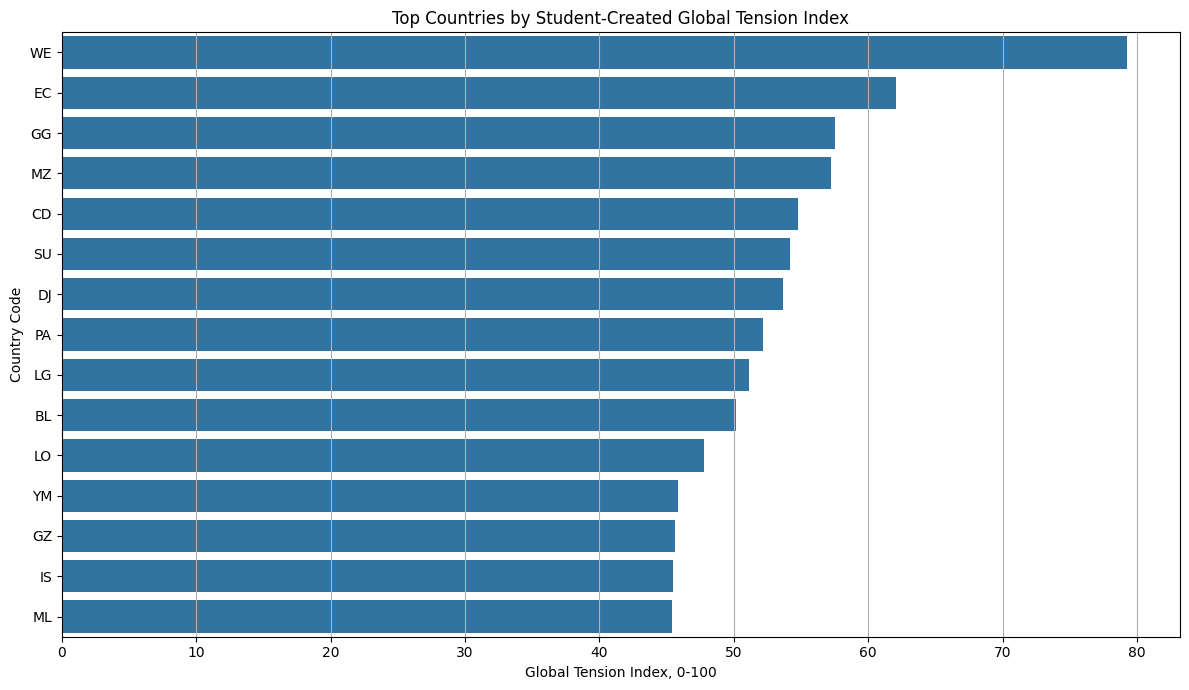

In [26]:
# ============================================================
# Cell 25: Bar chart — top countries by Global Tension Index
# ============================================================

top_tension = tension_ranked.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_tension,
    x="global_tension_index_0_100",
    y="ActionGeo_CountryCode"
)
plt.title("Top Countries by Student-Created Global Tension Index")
plt.xlabel("Global Tension Index, 0-100")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

**Interpretation:** The Global Tension Index is a simple descriptive score created for this project. Countries with higher values combine more negative tone, higher conflict share, stronger media attention, and lower Goldstein scores.

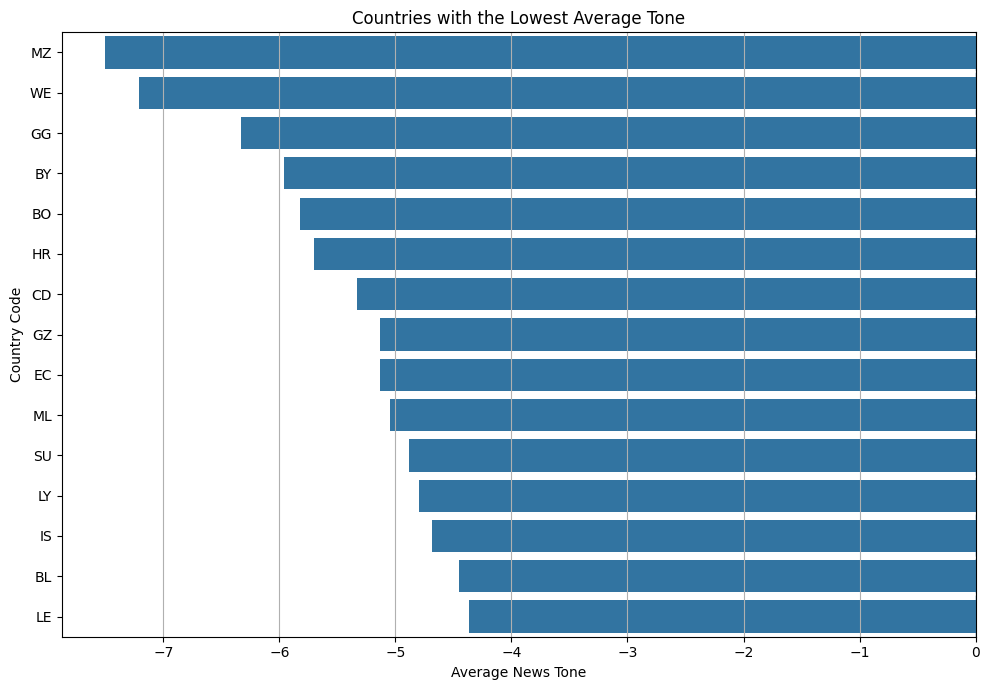

In [27]:
# ============================================================
# Cell 26: Bar chart — lowest average tone among ranked countries
# ============================================================

tone_rank = tension.sort_values("avg_tone").head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=tone_rank,
    x="avg_tone",
    y="ActionGeo_CountryCode"
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Countries with the Lowest Average Tone")
plt.xlabel("Average News Tone")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()


**Interpretation:** This chart focuses specifically on average tone by country. It is included as a lecture-friendly replacement for an advanced interactive map.

In [29]:
# ============================================================
# Cell 29: Export cleaned data and summary tables
# ============================================================

OUTPUT_DIR = Path("gdelt_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "cleaned_gdelt_events_sample.csv", index=False)
country_stats.to_csv(OUTPUT_DIR / "country_mood_conflict_stats.csv", index=False)
category_stats.to_csv(OUTPUT_DIR / "event_category_attention_stats.csv", index=False)
daily.to_csv(OUTPUT_DIR / "daily_event_intensity_stats.csv", index=False)
tension_ranked.to_csv(OUTPUT_DIR / "global_tension_index_country_ranking.csv", index=False)

print("Export complete.")
print(f"Files saved in: {OUTPUT_DIR.resolve()}")

Export complete.
Files saved in: /Users/beltinaa/Documents/world_mood_map_notebook/gdelt_outputs


# Conclusion

## Can News Tone Help Identify Patterns Related to Protests, Conflict, and Diplomacy?

This project used GDELT 2.0 event data to explore whether global media tone can
reveal patterns related to protest, conflict, and diplomatic activity.

The analysis suggests that **news tone, Goldstein Scale, event category, and media
attention can be combined to identify meaningful differences** between types of
reported global events. Countries and event types that score more negatively in
media coverage tend to be associated with conflict-related activity, while more
positive scores cluster around cooperative and diplomatic events.

However, several important limitations must be acknowledged:

- **Media reporting bias**: GDELT is built from media sources that may unevenly
  cover different regions. Countries with less English-language media coverage
  may appear calmer than they actually are.
- **Correlation is not causation**: A negative tone in reporting does not prove
  that conflict occurred, nor does a positive tone guarantee stability. Tone
  reflects how events are *framed*, not just what happened.
- **Sampling**: The dataset uses a balanced but limited sample. Conclusions should
  not be generalised to the full population of global events.
- **Event classification**: The event category labels are derived from CAMEO codes
  and simplified quadrant labels, which can miss nuance in complex events.

In summary, news tone is **partially useful** as a signal for identifying conflict-
oriented or cooperative periods in media coverage. It should be treated as a
descriptive indicator rather than a predictive tool. Used alongside event volume,
Goldstein Scale, and media attention, it can enrich understanding of how global
events are reported — and how that reporting varies across countries and time.

Future work could extend this analysis with a larger balanced sample, country-level
fixed effects, or sentiment models applied to full article text rather than the
pre-computed GDELT tone metric.